# Notebook 04: Universal Descriptor Extraction

This notebook extracts the universal descriptor fingerprint {Qmax, Eads, sigma_E} from fitted isotherm parameters and visualizes the descriptor space for comparison across different adsorbent-adsorbate systems.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils_isotherms import extract_descriptors

## Define fitted parameters for several hypothetical materials

Each material represents a different adsorbent-adsorbate system with fitted isotherm parameters from various models.

In [12]:
materials = [
    {'name': 'AC-phenol',     'model': 'Langmuir',  'params': {'Qmax': 150, 'KL': 0.08}},
    {'name': 'AC-methylene',  'model': 'Sips',      'params': {'Qmax': 200, 'KS': 0.05, 'm': 0.7}},
    {'name': 'Zeolite-Pb',    'model': 'Langmuir',  'params': {'Qmax': 80, 'KL': 0.3}},
    {'name': 'MOF-PFOA',      'model': 'Sips',      'params': {'Qmax': 300, 'KS': 0.02, 'm': 0.6}},
    {'name': 'Biochar-Cd',    'model': 'Jovanovic',  'params': {'Qmax': 50, 'b': 0.15}},
    {'name': 'Clay-atrazine', 'model': 'Toth',      'params': {'Qmax': 40, 'b': 0.1, 't': 0.5}},
    {'name': 'GO-Cr',         'model': 'Hill',      'params': {'Qmax': 180, 'KD': 50, 'nH': 0.8}},
    {'name': 'Resin-PFOS',    'model': 'Langmuir',  'params': {'Qmax': 250, 'KL': 0.5}},
]

## Extract universal descriptors

For each material, we extract the universal descriptor fingerprint using the `extract_descriptors` function. This converts model-specific parameters into comparable thermodynamic descriptors.

In [13]:
# Extract descriptors for all materials
descriptor_data = []

for mat in materials:
    desc = extract_descriptors(mat['model'], mat['params'], C0=1.0, T=298)
    descriptor_data.append({
        'Material': mat['name'],
        'Model': mat['model'],
        'Qmax': desc['Qmax'],
        'Kaff_star': desc['Kaff_star'],
        'Eads': desc['Eads'],
        'sigma_E': desc['sigma_E']
    })

# Create DataFrame
df_descriptors = pd.DataFrame(descriptor_data)
print("Universal Descriptors for All Materials:")
print("="*80)
display(df_descriptors)

Universal Descriptors for All Materials:


,Material,Model,Qmax,Kaff_star,Eads,sigma_E
0,AC-phenol,Langmuir,150,0.080000,-6.257675,0.000000
1,AC-methylene,Sips,200,0.013848,-10.603061,3.145673
2,Zeolite-Pb,Langmuir,80,0.300000,-2.982929,0.000000
3,MOF-PFOA,Sips,300,0.001474,-16.153864,2.696291
4,Biochar-Cd,Jovanovic,50,0.150000,-4.700251,3.177610
5,Clay-atrazine,Toth,40,0.100000,-5.704820,8.987637
6,GO-Cr,Hill,180,0.007521,-12.115398,5.617273
7,Resin-PFOS,Langmuir,250,0.500000,-1.717322,0.000000


## Visualize descriptor space

Plot the materials in the universal descriptor space (Eads vs Qmax), with point size representing heterogeneity (sigma_E) and color indicating the isotherm model type.

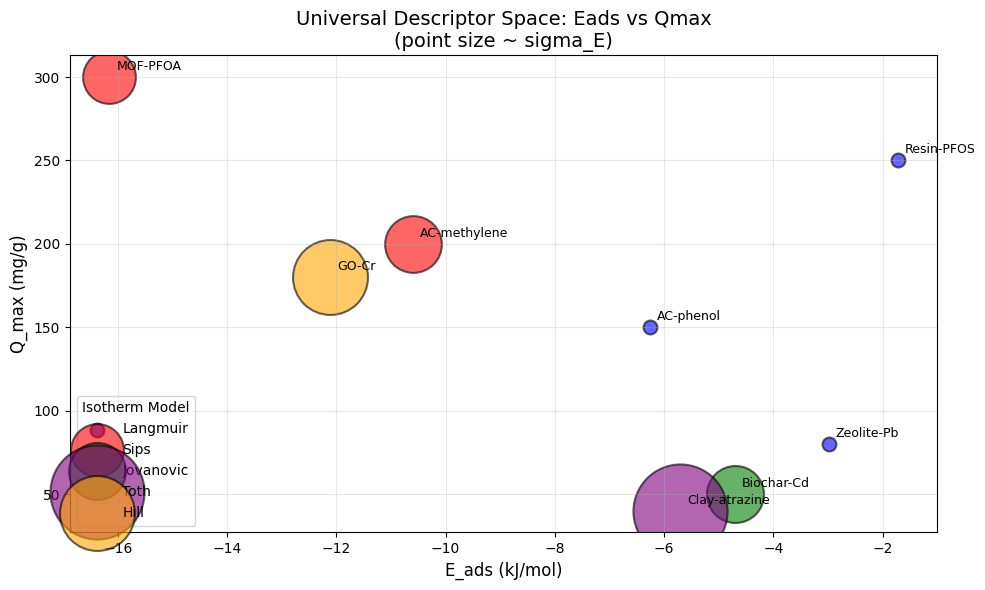

In [14]:
# Create scatter plot
fig, ax = plt.subplots(figsize=(10, 6))

# Define color map for different models
model_colors = {
    'Langmuir': 'blue',
    'Sips': 'red',
    'Jovanovic': 'green',
    'Toth': 'purple',
    'Hill': 'orange'
}

# Plot each material
for idx, row in df_descriptors.iterrows():
    color = model_colors.get(row['Model'], 'gray')
    # Size proportional to sigma_E (scaled for visibility)
    size = 100 + row['sigma_E'] * 500
    ax.scatter(row['Eads'], row['Qmax'], s=size, c=color, alpha=0.6, 
               edgecolors='black', linewidth=1.5, label=row['Model'])
    # Add material name labels
    ax.annotate(row['Material'], (row['Eads'], row['Qmax']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

# Remove duplicate labels in legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title='Isotherm Model', loc='best')

ax.set_xlabel('E_ads (kJ/mol)', fontsize=12)
ax.set_ylabel('Q_max (mg/g)', fontsize=12)
ax.set_title('Universal Descriptor Space: Eads vs Qmax\n(point size ~ sigma_E)', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Pairwise comparison: OVL between two Sips materials

We compute the overlap coefficient (OVL) between two materials fitted with the Sips model to quantify their similarity in the adsorption energy distribution space.

In [15]:
from utils_isotherms import compute_OVL_gaussian

# Extract descriptors for the two Sips materials
mof_pfoa = df_descriptors[df_descriptors['Material'] == 'MOF-PFOA'].iloc[0]
ac_methylene = df_descriptors[df_descriptors['Material'] == 'AC-methylene'].iloc[0]

# Compute OVL using Eads as Ec and sigma_E as sigma
# Signature: compute_OVL_gaussian(Ec_A, sigma_A, Ec_B, sigma_B)
ovl = compute_OVL_gaussian(
    mof_pfoa['Eads'], mof_pfoa['sigma_E'],
    ac_methylene['Eads'], ac_methylene['sigma_E']
)

print("Pairwise Comparison: MOF-PFOA vs AC-methylene")
print("="*60)
print(f"MOF-PFOA:      E_ads = {mof_pfoa['Eads']:.2f} kJ/mol, sigma_E = {mof_pfoa['sigma_E']:.3f}")
print(f"AC-methylene:  E_ads = {ac_methylene['Eads']:.2f} kJ/mol, sigma_E = {ac_methylene['sigma_E']:.3f}")
print(f"\nOverlap Coefficient (OVL) = {ovl:.4f}")
print("\nInterpretation:")
if ovl > 0.7:
    print("  High similarity - materials have very similar adsorption energy distributions")
elif ovl > 0.4:
    print("  Moderate similarity - materials share some common adsorption characteristics")
else:
    print("  Low similarity - materials have distinct adsorption energy distributions")

Pairwise Comparison: MOF-PFOA vs AC-methylene
MOF-PFOA:      E_ads = -16.15 kJ/mol, sigma_E = 2.696
AC-methylene:  E_ads = -10.60 kJ/mol, sigma_E = 3.146

Overlap Coefficient (OVL) = 0.3435

Interpretation:
  Low similarity - materials have distinct adsorption energy distributions
